# 01 — Exploratory Data Analysis

Pull SPY, plot price + 50/200 SMA, eyeball SMA cross signals.

In [7]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

from src.data.fetch import fetch_ohlcv
from src.strategies.sma_cross import SmaCross
from src.backtest.runner import run

prices = fetch_ohlcv('SPY', '2015-01-01')
prices.tail()

2026-05-09 15:10:03.877 | INFO     | src.data.fetch:fetch_ohlcv:17 - fetch SPY 2015-01-01->None interval=1d


,close,high,low,open,volume
date,,,,,
2026-05-04,718.010010,722.119995,714.989990,720.070007,51950600
2026-05-05,723.770020,725.039978,721.489990,721.770020,36933200
2026-05-06,733.830017,734.590027,727.820007,728.159973,53288900
2026-05-07,731.580017,736.130005,729.750000,735.049988,51724600
2026-05-08,737.619995,738.080017,734.570007,734.929993,47172700


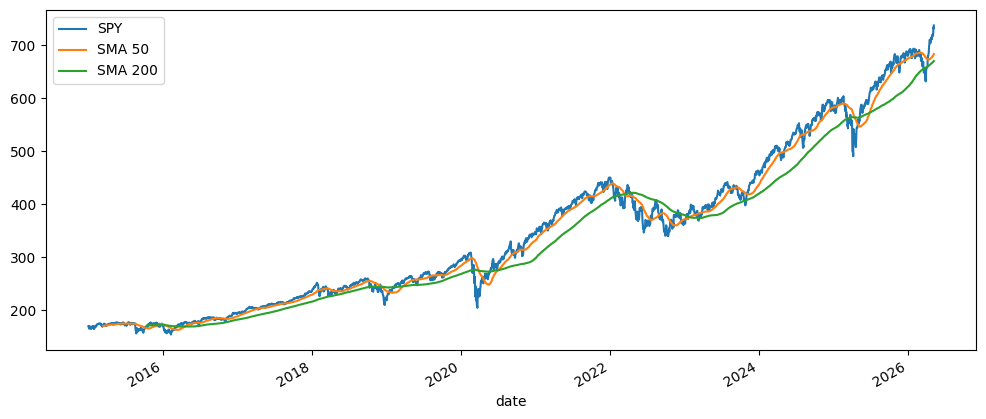

In [8]:
ax = prices['close'].plot(figsize=(12, 5), label='SPY')
prices['close'].rolling(50).mean().plot(ax=ax, label='SMA 50')
prices['close'].rolling(200).mean().plot(ax=ax, label='SMA 200')
ax.legend()

In [10]:
result = run(prices, SmaCross(50, 200))
print(result.summary())
result.portfolio.plot().show()

return=-6.98% sharpe=0.10 mdd=-35.26% trades=49


/app/.venv/lib/python3.11/site-packages/vectorbt/generic/plots_builder.py:339: UserWarning: Subplot 'orders' does not support grouped data
  warnings.warn(warning_message)
/app/.venv/lib/python3.11/site-packages/vectorbt/generic/plots_builder.py:339: UserWarning: Subplot 'trade_pnl' does not support grouped data
  warnings.warn(warning_message)


ImportError: Please install anywidget to use the FigureWidget class